In [104]:
from langchain_community.document_loaders import PyPDFLoader

In [105]:
loader = PyPDFLoader("data/Samsung_Card_Manual_Korean_1.3.pdf")
pages = loader.load()  # List[Document] 형태로 반환


In [106]:
from dotenv import load_dotenv
load_dotenv(r"c:\Users\Admin\hipython\learning\llm\.env", override=True)

True

In [107]:
len(pages)

6

In [108]:
pages[0].page_content[:100]
pages[0].metadata

{'producer': 'Microsoft® Word 2010',
 'creator': 'Microsoft® Word 2010',
 'creationdate': '2019-01-02T09:40:06+09:00',
 'author': 'master',
 'moddate': '2019-01-02T09:40:06+09:00',
 'source': 'data/Samsung_Card_Manual_Korean_1.3.pdf',
 'total_pages': 6,
 'page': 0,
 'page_label': '1'}

# 인덱싱

## 청킹

In [109]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [110]:
splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=100)
docs = splitter.split_documents(pages)

In [111]:
docs[0].page_content

'사용설명서           SAMSUNG PROPRIETARY \nRevision1.3 \n1 \n \n \n \n \n \n \n \n \n \n \n \n \n \n. \n \n법적 고지 사항 \n삼성 전자는 통지 없이 제품, 정보 및 사양을 변경할 권리를 보유합니다.  \n여기에 언급된 제품 및 사양은 참조용으로만 사용되며, 여기에 언급된 모든 정보는 공지 없이 변경될 수 있고 \n어떠한 종류의 보증도 없이 "있는 그대로" 제공됩니다. 본 문서 및 여기에 명시된 모든 정보는 삼성 전자의 \n유일하고 배타적인 자산으로 보유됩니다. 본 문서에 따라 어떠한 특허권, 저작권, 마스크워크, 상표 또는 기타 \n지적 재산권도 묵시적, 금반언적 또는 기타 어떤 방식으로도 한 당사자가 다른 당사자에게 부여할 수 없습니다. \n삼성 제품은 생명 보조기구, 구명의료기, 의료 기기, 안전 장비 또는 제품의 오류로 인해 사망, 부상 또는 물리적'

## 임베딩

In [112]:
from langchain_openai import OpenAIEmbeddings, ChatOpenAI

In [113]:
embeddings = OpenAIEmbeddings()

In [114]:
# !pip install faiss-cpu --no-cache-dir

In [115]:
from langchain_community.vectorstores import FAISS

In [116]:
vectordb = FAISS.from_documents(docs, embeddings)

In [117]:
vectordb

# 검색

In [118]:
retriever = vectordb.as_retriever(search_kwargs={"k":3})

## 프롬프트

In [119]:
from langchain_core.prompts import ChatPromptTemplate

In [120]:
msg = """"
너는 삼성전자 메모리카드 매뉴얼에 대한 전문 어시스턴트이다.
다음의 참고 문서를 바탕으로 질문에 정확하게 답하라.

[참고문서]
{context}

[질문]
{question}

한글로 간결하고 정확하게 답변하라."""

In [121]:
prompt = ChatPromptTemplate.from_template(msg)

## 응답생성

In [122]:
llm = ChatOpenAI(model='gpt-4o-mini', temperature=0)

In [123]:
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser


rag_chain = (
    {"context": retriever, "question": RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser()
)

query = "이 유틸리티는 동시에 몇 개의 메모리카드나 UFD를 인식할 수 있나?"  # 예시 질의
answer = rag_chain.invoke(query)

In [124]:
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser


rag_chain = (
    {"context": retriever, "question": RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser()
)

query2 = "이 유틸리티는 어떤 운영체제에서 작동하는가?"  # 예시 질의
answer2 = rag_chain.invoke(query2)

In [125]:
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser


rag_chain = (
    {"context": retriever, "question": RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser()
)

query3 = "PC에 연결된 card나 ufd 제품이 없는 경우 어떤 메세지를 반환하는가"  # 예시 질의
answer3 = rag_chain.invoke(query3)

In [132]:
from langchain_core.runnables import RunnablePassthrough
from langchain_core.output_parsers import StrOutputParser


rag_chain = (
    {"context": retriever, "question": RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser()
)

query4 = "인증 가능라는 문구는 어떤 경우에 표시가 되어있는가?"  # 예시 질의
answer4 = rag_chain.invoke(query4)

### RAG의 결과

In [126]:
answer

'이 유틸리티는 동시에 최대 8개의 메모리 카드나 UFD를 인식할 수 있습니다.'

In [127]:
answer2

'이 유틸리티는 Windows 7(32/64비트), Windows 8 및 8.1(32/64비트), Windows 10(32/64비트)에서 작동합니다.'

In [128]:
answer3

'PC에 연결된 카드나 UFD 제품이 없는 경우 유틸리티에서 "메모리 카드/USB 플래시 드라이브 삽입(Insert a Memory card / USB Flash Drive)" 메시지를 표시합니다.'

In [133]:
answer4

'"인증 가능(Authentication Available)"라는 문구는 UFD 제품(Bar Plus)의 포장에 표시되어 있습니다.'

### LLM의 결과

In [129]:
llm.invoke(query)

AIMessage(content='이 유틸리티가 동시에 인식할 수 있는 메모리 카드나 USB 플래시 드라이브(UFD)의 개수는 사용 중인 하드웨어와 소프트웨어에 따라 다릅니다. 일반적으로, 대부분의 운영 체제는 여러 개의 USB 장치를 동시에 인식할 수 있으며, USB 허브를 사용하면 더 많은 장치를 연결할 수 있습니다. 그러나 각 장치의 성능이나 전원 공급, 드라이버 호환성 등에 따라 인식 가능 개수가 제한될 수 있습니다. 특정 유틸리티에 대한 정보가 필요하다면, 해당 유틸리티의 공식 문서나 지원 페이지를 참조하는 것이 좋습니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 149, 'prompt_tokens': 34, 'total_tokens': 183, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_a80228f72e', 'id': 'chatcmpl-DU1qj5BAtFTueI0ZBMrjwBGA8XoTY', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d84c9-fca3-79f3-99ee-0687b5422b84-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 34

In [130]:
llm.invoke(query2)

AIMessage(content='어떤 유틸리티를 말씀하시는지 구체적으로 알려주시면, 해당 유틸리티가 어떤 운영체제에서 작동하는지 더 정확하게 답변해드릴 수 있습니다. 일반적으로 유틸리티는 특정 운영체제에 맞춰 개발되기 때문에, 각 유틸리티의 시스템 요구 사항을 확인하는 것이 중요합니다. 예를 들어, Windows, macOS, Linux 등 다양한 운영체제에서 작동할 수 있는 유틸리티가 있습니다. 추가 정보를 주시면 더 도움을 드릴 수 있습니다!', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 124, 'prompt_tokens': 24, 'total_tokens': 148, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_a80228f72e', 'id': 'chatcmpl-DU1qmnPLTmeW8nr5seTk1GlZnoCnH', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d84ca-08a3-7180-85d2-cd85e79eaad1-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 24, 'output_tokens': 124, 'total_tokens': 148, 'in

In [131]:
llm.invoke(query3)

AIMessage(content='PC에 연결된 카드나 USB 플래시 드라이브(UFD) 제품이 없는 경우, 일반적으로 운영 체제나 특정 소프트웨어에서 다음과 같은 메시지를 반환할 수 있습니다:\n\n1. **Windows**: "디스크를 삽입하세요" 또는 "장치가 연결되어 있지 않습니다."\n2. **macOS**: "장치가 감지되지 않았습니다." 또는 "디스크가 없습니다."\n3. **리눅스**: "장치가 연결되어 있지 않습니다." 또는 "파일 시스템을 마운트할 수 없습니다."\n\n이 메시지는 사용 중인 소프트웨어나 드라이버에 따라 다를 수 있으며, 특정 프로그램에서는 사용자 정의 오류 메시지를 표시할 수도 있습니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 156, 'prompt_tokens': 26, 'total_tokens': 182, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_a80228f72e', 'id': 'chatcmpl-DU1qp5D9gshkzdR7kNuqgzEv83no9', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019d84ca-1174-7243-87b0-e6c8e40088a7-0', tool_calls=[], invali

In [134]:
llm.invoke(query4)

AIMessage(content='"인증 가능"이라는 문구는 일반적으로 특정 제품이나 서비스가 인증을 받을 수 있는 조건을 충족하고 있음을 나타냅니다. 이 문구는 다음과 같은 경우에 표시될 수 있습니다:\n\n1. **제품 인증**: 전자기기, 소프트웨어, 의료기기 등에서 해당 제품이 특정 기준이나 규정을 충족하여 인증을 받을 수 있음을 나타냅니다.\n\n2. **서비스 인증**: 클라우드 서비스, 보안 서비스 등에서 해당 서비스가 특정 보안 기준이나 품질 기준을 충족할 수 있음을 의미합니다.\n\n3. **교육 및 훈련 프로그램**: 특정 교육 과정이나 훈련 프로그램이 인증 기관의 기준을 충족하여 인증을 받을 수 있는 경우에 사용됩니다.\n\n4. **기업 인증**: 기업이 특정 산업 표준이나 인증 프로그램에 따라 인증을 받을 수 있는 경우에 표시될 수 있습니다.\n\n이 문구는 소비자에게 해당 제품이나 서비스가 신뢰할 수 있는 기준을 충족하고 있다는 정보를 제공하기 위해 사용됩니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 224, 'prompt_tokens': 23, 'total_tokens': 247, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_a80228f72e', 'id': 'chatcmpl-DU1sKkhQvhnLKmFUExGtp1ACnd

# 파인콘

In [143]:
from dotenv import load_dotenv
load_dotenv(r"c:\Users\Admin\hipython\learning\llm\.env", override=True)

from pinecone import Pinecone

pc = Pinecone(api_key=os.environ['PINECONE_API_KEY'])

In [142]:
# 인덱스 목록 확인
indexes = pc.list_indexes().names()
print(f"생성된 인덱스: {indexes}")

# 인덱스 상태 확인
index_name = os.environ['PINECONE_INDEX_NAME']
if index_name in indexes:
    index = pc.Index(index_name)
    stats = index.describe_index_stats()
    print(f"벡터 수: {stats['total_vector_count']}")
    print(f"dimension: {stats['dimension']}")

생성된 인덱스: ['embedding-3d']


In [ ]:
from pinecone import Pinecone, ServerlessSpec

pc.create_index(
    name="embedding-3d",        # 인덱스 이름
    dimension=3,                # 벡터 차원 (반드시 맞춰야 함)
    metric="cosine",            # 유사도 측정 방식
    spec=ServerlessSpec(
        cloud="aws",            # 클라우드
        region="us-east-1"      # 리전
    )
)

In [146]:
index = pc.Index("embedding-3d")
index.describe_index_stats()


{'dimension': 3,
 'index_fullness': 0.0,
 'metric': 'cosine',
 'namespaces': {},
 'total_vector_count': 0,
 'vector_type': 'dense'}

In [147]:
# 벡터를 인덱스에 업서트(upsert)합니다.
# "embedding-3d-ns1" 네임스페이스에 벡터를 추가합니다.
index.upsert(
    vectors=[
        {
            "id": "vec1",
            "values": [1.0, 1.5, 2.0],
            "metadata": {"genre": "drama"}
        }, {
            "id": "vec2",
            "values": [2.0, 1.0, 0.5],
            "metadata": {"genre": "action"}
        }, {
            "id": "vec3",
            "values": [0.1, 0.3, 0.5],      #vector=[0.1, 0.3, 0.7],
            "metadata": {"genre": "drama"}
        }, {
            "id": "vec4",
            "values": [1.0, 2.5, 3.5],      #vector=[0.1, 0.3, 0.7],
            "metadata": {"genre": "action"}
        }, {
            "id": "vec5",
            "values": [3.0, 1.2, 1.3],
            "metadata": {"genre": "action"}
        }, {
            "id": "vec6", 
            "values": [0.3, 1.1, 2.5],  #    vector=[0.1, 0.3, 0.7],
            "metadata": {"genre": "drama"}
        }
    ],
    namespace="embedding-3d-ns1"
)

{'upserted_count': 6}

In [148]:
for ids in index.list(namespace="embedding-3d-ns1"):
    print(ids)

['vec1', 'vec2', 'vec3', 'vec4', 'vec5', 'vec6']


In [155]:
response = index.query(
    namespace="embedding-3d-ns1",
    vector=[0.1, 0.3, 0.9],
    top_k=3,
    include_values=True,
    include_metadata=True,
    filter= {"genre" :{"$eq":"drama"}}
)

print(response)

{'matches': [{'id': 'vec6',
              'metadata': {'genre': 'drama'},
              'score': 0.99634,
              'values': [0.3, 1.1, 2.5]},
             {'id': 'vec3',
              'metadata': {'genre': 'drama'},
              'score': 0.975393534,
              'values': [0.1, 0.3, 0.5]},
             {'id': 'vec1',
              'metadata': {'genre': 'drama'},
              'score': 0.915597081,
              'values': [1.0, 1.5, 2.0]}],
 'namespace': 'embedding-3d-ns1',
 'usage': {'read_units': 1}}


In [157]:
from itertools import chain

ns = "embedding-3d-ns1"

# ID 전부 모으기 (list()는 페이지 단위로 ID 리스트를 내줌)
all_ids = list(chain.from_iterable(index.list(namespace=ns)))

# 벡터 가져오기
resp = index.fetch(ids=all_ids, namespace=ns)   # ← FetchResponse 객체
vec_map = resp.vectors                          # dict[str, Vector]

# 값/메타데이터 사용 예
for vid, v in vec_map.items():
    print(vid, v.values)         # 값(list[float])
    # print(v.metadata)          # 메타데이터가 있으면
    
ids = list(vec_map.keys())
values = [vec.values for vec in vec_map.values()]

# 새 쿼리 벡터 추가
ids.append("qv")
values.append([0.1, 0.3, 0.7])   # <- dim=3 환경과 일치

print(ids)
print(values)    

vec3 [0.1, 0.3, 0.5]
vec1 [1.0, 1.5, 2.0]
vec4 [1.0, 2.5, 3.5]
vec6 [0.3, 1.1, 2.5]
vec5 [3.0, 1.2, 1.3]
vec2 [2.0, 1.0, 0.5]
['vec3', 'vec1', 'vec4', 'vec6', 'vec5', 'vec2', 'qv']
[[0.1, 0.3, 0.5], [1.0, 1.5, 2.0], [1.0, 2.5, 3.5], [0.3, 1.1, 2.5], [3.0, 1.2, 1.3], [2.0, 1.0, 0.5], [0.1, 0.3, 0.7]]


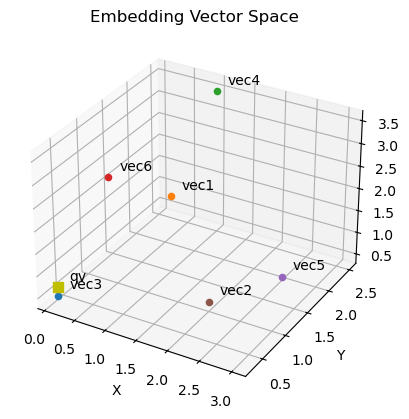

In [158]:
import matplotlib.pyplot as plt

# 3D 플롯을 생성합니다.
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# 각 벡터의 ID와 값을 사용하여 3D 공간에 점을 그립니다.
for i, id in enumerate(ids):
    if id == "qv":
        # 쿼리 벡터는 노란색 사각형으로 표시합니다.
        ax.scatter(values[i][0], values[i][1], values[i][2], label=id, color='y', s=50, marker='s')
        ax.text(values[i][0] + 0.1, values[i][1] + 0.1, values[i][2] + 0.1, id)
    else:
        # 나머지 벡터는 기본 색상으로 표시합니다.
        ax.scatter(values[i][0], values[i][1], values[i][2], label=id)
        ax.text(values[i][0] + 0.1, values[i][1] + 0.1, values[i][2] + 0.1, id)

# 축 레이블과 제목을 설정합니다.
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('Embedding Vector Space')

# 플롯을 표시합니다.
plt.show()

# Wiki 인덱스

In [226]:
# Pinecone 인덱스를 생성합니다.
# 인덱스 이름은 "wiki"이고, 차원은 1536, 메트릭은 코사인 유사도를 사용합니다.
# 인덱스는 AWS의 us-east-1 리전에서 서버리스 사양으로 생성됩니다.
index_name = "wiki"

pc.create_index(
    name=index_name,
    dimension=1536,  # 모델 차원
    metric="cosine",  # 모델 메트릭
    spec=ServerlessSpec(
        cloud="aws",
        region="us-east-1"
    )
)

{
    "name": "wiki",
    "metric": "cosine",
    "host": "wiki-0silf5u.svc.aped-4627-b74a.pinecone.io",
    "spec": {
        "serverless": {
            "cloud": "aws",
            "region": "us-east-1"
        }
    },
    "status": {
        "ready": true,
        "state": "Ready"
    },
    "vector_type": "dense",
    "dimension": 1536,
    "deletion_protection": "disabled",
    "tags": null
}

In [227]:
# 'wiki' 인덱스를 가져옵니다.
index = pc.Index(index_name)


In [228]:
# 인덱스의 통계 정보를 설명합니다.
index.describe_index_stats()

{'dimension': 1536,
 'index_fullness': 0.0,
 'metric': 'cosine',
 'namespaces': {},
 'total_vector_count': 0,
 'vector_type': 'dense'}

In [229]:
from datasets import load_dataset

# 예: 2023-11-01 덤프의 한국어(ko) 전체 학습 split, # 언어/스냅샷 선택
data = load_dataset("wikimedia/wikipedia", "20231101.ko", split="train[:100]")
print(data)
print(data[0])  # {'id', 'url', 'title', 'text', 'timestamp' ... 형식}

Dataset({
    features: ['id', 'url', 'title', 'text'],
    num_rows: 100
})
{'id': '5', 'url': 'https://ko.wikipedia.org/wiki/%EC%A7%80%EB%AF%B8%20%EC%B9%B4%ED%84%B0', 'title': '지미 카터', 'text': '제임스 얼 카터 주니어(, 1924년 10월 1일~)는 민주당 출신 미국의 제39대 대통령(1977년~1981년)이다.\n\n생애\n\n어린 시절 \n지미 카터는 조지아주 섬터 카운티 플레인스 마을에서 태어났다.\n\n조지아 공과대학교를 졸업하였다. 그 후 해군에 들어가 전함·원자력·잠수함의 승무원으로 일하였다. 1953년 미국 해군 대위로 예편하였고 이후 땅콩·면화 등을 가꿔 많은 돈을 벌었다. 그의 별명이 "땅콩 농부" (Peanut Farmer)로 알려졌다.\n\n정계 입문 \n1962년 조지아주 상원 의원 선거에서 낙선하였으나, 그 선거가 부정선거 였음을 입증하게 되어 당선되고, 1966년 조지아 주지사 선거에 낙선하지만, 1970년 조지아 주지사 선거에서 당선됐다. 대통령이 되기 전 조지아주 상원의원을 두번 연임했으며, 1971년부터 1975년까지 조지아 지사로 근무했다. 조지아 주지사로 지내면서, 미국에 사는 흑인 등용법을 내세웠다.\n\n대통령 재임 \n\n1976년 미합중국 제39대 대통령 선거에 민주당 후보로 출마하여 도덕주의 정책으로 내세워서, 많은 지지를 받았는데 제럴드 포드 대통령을 누르고 당선되었다.\n\n카터 대통령은 에너지 개발을 촉구했으나 공화당의 반대로 무산되었다.\n\n외교 정책 \n카터는 이집트와 이스라엘을 조정하여 캠프 데이비드에서 안와르 사다트 대통령과 메나헴 베긴 수상과 함께 중동 평화를 위한 캠프데이비드 협정을 체결했다. 이것은 공화당과 미국의 유대인 단체의 반발을 일으켰다. 그러나 1979년, 양국 간의 평화조약이 백악관에서 이루어졌다.\n\n소련과 제2차 전략 무기 제한 

In [230]:
embedding_model = OpenAIEmbeddings(model="text-embedding-3-small")

In [231]:
print(data[0]["text"])

제임스 얼 카터 주니어(, 1924년 10월 1일~)는 민주당 출신 미국의 제39대 대통령(1977년~1981년)이다.

생애

어린 시절 
지미 카터는 조지아주 섬터 카운티 플레인스 마을에서 태어났다.

조지아 공과대학교를 졸업하였다. 그 후 해군에 들어가 전함·원자력·잠수함의 승무원으로 일하였다. 1953년 미국 해군 대위로 예편하였고 이후 땅콩·면화 등을 가꿔 많은 돈을 벌었다. 그의 별명이 "땅콩 농부" (Peanut Farmer)로 알려졌다.

정계 입문 
1962년 조지아주 상원 의원 선거에서 낙선하였으나, 그 선거가 부정선거 였음을 입증하게 되어 당선되고, 1966년 조지아 주지사 선거에 낙선하지만, 1970년 조지아 주지사 선거에서 당선됐다. 대통령이 되기 전 조지아주 상원의원을 두번 연임했으며, 1971년부터 1975년까지 조지아 지사로 근무했다. 조지아 주지사로 지내면서, 미국에 사는 흑인 등용법을 내세웠다.

대통령 재임 

1976년 미합중국 제39대 대통령 선거에 민주당 후보로 출마하여 도덕주의 정책으로 내세워서, 많은 지지를 받았는데 제럴드 포드 대통령을 누르고 당선되었다.

카터 대통령은 에너지 개발을 촉구했으나 공화당의 반대로 무산되었다.

외교 정책 
카터는 이집트와 이스라엘을 조정하여 캠프 데이비드에서 안와르 사다트 대통령과 메나헴 베긴 수상과 함께 중동 평화를 위한 캠프데이비드 협정을 체결했다. 이것은 공화당과 미국의 유대인 단체의 반발을 일으켰다. 그러나 1979년, 양국 간의 평화조약이 백악관에서 이루어졌다.

소련과 제2차 전략 무기 제한 협상(SALT II)에 조인했다.

카터는 1970년대 후반 당시 대한민국 등 인권 후진국의 국민들의 인권을 지키기 위해 노력했으며, 취임 이후 계속해서 도덕정치를 내세웠다.

임기 말, 소련의 아프가니스탄 침공 사건으로 인해 1980년 하계 올림픽에 반공국가들의 보이콧을 하였다.

그는 주이란 미국 대사관 인질 사건의 인질 구출 실패로 인한 원인으로, 1980년 제40대 대통령 선거에

In [232]:
len(data[0]["text"])

3608

In [233]:
len(data[1]["text"])

5087

In [234]:
len(data[2]["text"])

872

In [235]:
for record in data:
    if len(record["text"]) > 3500:
        print(record["id"], len(record["text"]), record["title"])


5 3608 지미 카터
9 5087 수학
21 8109 화학
22 3559 체첸 공화국
24 7023 맥스웰 방정식
26 4763 초월수
34 7361 대한민국 제16대 대통령 선거
36 8587 함석헌
38 11401 백남준
39 13555 2002년
42 3582 6월 30일
44 10135 우크라이나
49 3668 위키
65 5203 겐지모노가타리
70 4042 일반 상대성이론
76 4181 주기율표
77 17204 아미노산
80 3961 토마스 만
85 72992 노무현
91 4104 벡터 공간
139 7234 아쿠타가와 류노스케
140 4660 장국영
141 11038 통계학
143 9873 컴퓨터 과학
145 11331 위키백과
155 4705 자연철학의 수학적 원리
158 3728 엔트로피
171 5390 로봇
174 5888 표준 모형
187 8469 구글
195 4627 빅토르 초이
228 14699 막스 플랑크
233 3619 행렬식
239 7616 양자역학
245 37097 베르너 하이젠베르크
246 9599 중국의 역사


In [236]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

# RecursiveCharacterTextSplitter를 초기화합니다.
# 이 클래스는 텍스트를 재귀적으로 문자 단위로 분할합니다.
splitter = RecursiveCharacterTextSplitter(
    chunk_size=600,
    #chunk_size=1000,  # 분할할 텍스트의 크기
    #chunk_size=2048,  # 분할할 텍스트의 크기
    #chunk_overlap=100,  # 분할된 텍스트의 중첩 크기
    chunk_overlap=80,
    length_function=len,  # 텍스트 길이를 계산하는 함수
    separators=["\n\n", "\n", ". ", "다. ", " ", ""],
)

splitter

In [237]:
# 현재 설정으로 문서가 몇 개의 청크로 나뉘는지 확인합니다.
sample_indices = [0, 1, 2, 85]

for i in sample_indices:
    text = data[i]["text"]
    chunks = splitter.split_text(text)
    print(f"[{i}] {data[i]['title']}")
    print(f"text length: {len(text)} -> {len(chunks)} chunks")
    print("chunk lengths:", [len(chunk) for chunk in chunks[:10]])
    print()


[0] 지미 카터
text length: 3608 -> 7 chunks
chunk lengths: [566, 474, 589, 509, 517, 471, 495]

[1] 수학
text length: 5087 -> 13 chunks
chunk lengths: [533, 569, 403, 258, 539, 367, 401, 284, 2, 413]

[2] 수학 상수
text length: 872 -> 2 chunks
chunk lengths: [581, 356]

[85] 빅토르 초이
text length: 4627 -> 13 chunks
chunk lengths: [103, 5, 572, 194, 338, 410, 531, 438, 300, 362]



In [238]:
from tqdm.auto import tqdm
from uuid import uuid4
import time

batch_size = 20  #한 번에 올린 upsert 요청 바디가 3MB, Pinecone 서버의 2MB 제한을 넘으면 오류 > 배치사이즈 작게 하기
texts = []
metas = []
count = 0


In [239]:
# 데이터셋의 각 샘플에 대해 반복합니다.
for i, sample in enumerate(tqdm(data)):

    full_text = sample["text"] # Wikipedia 문서 텍스트
    metadata = {
        'wiki_id': str(sample["id"]),  # Wikipedia 문서 ID
        'url': sample["url"],  # Wikipedia 문서 URL
        'title': sample["title"],  # Wikipedia 문서 제목
    }

		# 텍스트를 청크로 분할합니다.
    chunks = splitter.split_text(full_text)  # 텍스트를 청크로 분할합니다.
    print(len(chunks))

    # 각 청크에 대해 반복합니다.
    for i, chunk in enumerate(chunks):
        chunk_text = f"제목: {sample['title']}\n\n{chunk}"
        record = {
            'chunk_id': i,  # 청크 ID
            'text': chunk_text,
            #'full_text': full_text,  # 전체 텍스트
            **metadata,  # 메타데이터 언패킹
        }

        texts.append(chunk_text)  # 청크를 텍스트 목록에 추가합니다.
        metas.append(record)  # 메타데이터를 메타데이터 목록에 추가합니다.

        count += 1  # 처리된 청크 수를 증가시킵니다.

        # batch_size만큼의 청크를 처리할 때마다 청크를 Pinecone 인덱스에 추가합니다.
        if count % batch_size == 0:
            # Pinecone 인덱스에 청크를 추가합니다.
            ids = [str(uuid4()) for _ in range(len(texts))]
            batch_embeddings = embedding_model.embed_documents(texts)
            index.upsert(
                vectors=zip(ids, batch_embeddings, metas),
                namespace="wiki-ns3")
            # 청크 목록과 메타데이터 목록을 비웁니다.
            texts = []
            metas = []
            # 1초 대기합니다.
            time.sleep(1)

if texts:
    ids = [str(uuid4()) for _ in range(len(texts))]
    batch_embeddings = embedding_model.embed_documents(texts)
    index.upsert(
        vectors=zip(ids, batch_embeddings, metas),
        namespace="wiki-ns3",
    )


  0%|          | 0/100 [00:00<?, ?it/s]

7
13


  2%|▏         | 2/100 [00:04<03:34,  2.19s/it]

2
8
6
18


  6%|▌         | 6/100 [00:08<02:02,  1.30s/it]

...

 97%|█████████▋| 97/100 [03:19<00:04,  1.35s/it]

3
91


 99%|█████████▉| 99/100 [03:38<00:03,  3.01s/it]

24


100%|██████████| 100/100 [03:43<00:00,  2.24s/it]


In [240]:
from langchain_pinecone import PineconeVectorStore

In [241]:
vectorstore = PineconeVectorStore.from_existing_index(
  index_name= 'wiki',
  embedding= embedding_model,
  text_key = "text",
  namespace = "wiki-ns3"
)

In [242]:
results = vectorstore.similarity_search_with_score(
  query = "대한민국의 수도는 어디인가요?",
  k=5,
  namespace="wiki-ns3"
)
print(f"결과 수: {len(results)}")
for i, (r, score) in enumerate(results):
  print(f"\n[ {i+1}]")
  print(f"score: {score}")
  print(f"page_content: {r.page_content[:100]}")
  print(f"metadata: {r.metadata}")

결과 수: 5

[ 1]
score: 0.381928176
page_content: 제목: 나라 이름순 수도 목록

ㅌ 

 타지키스탄 - 두샨베
 탄자니아 - 도도마
 태국 - 방콕
 튀르키예 - 앙카라
 토고 - 로메
 통가 - 누쿠알로파
 투르크메니스탄 - 
metadata: {'chunk_id': 7.0, 'title': '나라 이름순 수도 목록', 'url': 'https://ko.wikipedia.org/wiki/%EB%82%98%EB%9D%BC%20%EC%9D%B4%EB%A6%84%EC%88%9C%20%EC%88%98%EB%8F%84%20%EB%AA%A9%EB%A1%9D', 'wiki_id': '79'}

[ 2]
score: 0.378139526
page_content: 제목: 나라 이름순 수도 목록

ㅈ 

 자메이카 - 킹스턴
 잠비아 - 루사카
 적도 기니 - 말라보
 조선민주주의인민공화국 - 평양
 조지아 - 트빌리시
 중앙아프리카 공화국 
metadata: {'chunk_id': 6.0, 'title': '나라 이름순 수도 목록', 'url': 'https://ko.wikipedia.org/wiki/%EB%82%98%EB%9D%BC%20%EC%9D%B4%EB%A6%84%EC%88%9C%20%EC%88%98%EB%8F%84%20%EB%AA%A9%EB%A1%9D', 'wiki_id': '79'}

[ 3]
score: 0.376680911
page_content: 제목: 노무현

2004년 10월 21일 헌법재판소는 "신행정수도특별법은 서울을 수도로 보아온 관습헌법에 어긋나는 일"이라며 수도 이전은 위헌이라는 판결을 내렸다. 수도는 서울이라
metadata: {'chunk_id': 50.0, 'title': '노무현', 'url': 'https://ko.wikipedia.org/wiki/%EB%85%B8%EB%AC%B4%ED%98%84', 'wiki_id': '85'}

[ 4]
score: 0.368588209
page_content: 제